# 01-分析対象とするVINの絞り込み

セグメンテーションの対象とするVIN（オーナー保有車両）を決定します。
決定条件は
- サーキット訪問頻度（サーキットが所有する車両を除外）
- GR Garage訪問頻度（ディーラーが保有する車両を除外）
- 走行距離（運転されていない車両を除外）
- トリップ数（運転されていない車両を除外）

In [0]:
# カレントディレクトリを変更
import os
os.chdir('../')

# 必要なライブラリをインストール
!pip install snowflake-snowpark-python==1.39.0
!pip install -r requirements.txt

  Obtaining dependency information for snowflake-snowpark-python==1.39.0 from https://files.pythonhosted.org/packages/75/5c/88f3602c81fdc96608da7b5f48212069c1ae8b3e9bb3f67efebf9c0abd46/snowflake_snowpark_python-1.39.0-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/164.8 kB ? eta -:--:--
     ━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/164.8 kB 1.5 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 2.5 MB/s eta 0:00:00
  Obtaining dependency information for snowflake-connector-python<4.0.0,>=3.17.0 from https://files.pythonhosted.org/packages/8a/bb/8213c682ea69cf50ba028db47469455cb7dba31b152b867ac3a468dcca19/snowflake_connector_python-3.18.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/74.8 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.5 MB/s eta 0:00:00
  Obtaining dependency information for tzlocal from https://files.pythonho

In [0]:
# python再起動
%restart_python

In [0]:
# 必要なモジュールをインポート
import os
import warnings
from dotenv import load_dotenv
os.chdir('../') # カレントディレクトリを変更
from src.query_utils import *
from src.plot_utils import *
from src.select_target_vin import *
from src.utils import *
warnings.simplefilter("ignore")
load_dotenv(".env")

# Snowflakeセッションを生成
snowflake_params = {
    "account": os.getenv("SNOWFLAKE_ACCOUNT"),
    "user": os.getenv("SNOWFLAKE_USER"),
    "database": os.getenv("SNOWFLAKE_DB"),
}
session = get_snowflake_session(snowflake_params)

In [0]:
# VAPのテーブル名を辞書化
vap_table_name_dict = {
    "202410": os.getenv("SNOWFLAKE_TABLE_952W_202410"),
    "202504": os.getenv("SNOWFLAKE_TABLE_952W_202504"),
    "202510": os.getenv("SNOWFLAKE_TABLE_952W_202510"),
}

## その年月で新しく出現したVINを特定

In [0]:
# Snowflakeからデータ抽出を行っていない場合はこちらを実行
# 【注意】処理に時間がかかります

# 抽出結果を保存するディレクトリとファイル名
SAVE_DIR = 'notebook/data/01_select_target_vin'
FILE_NAME = '952w_unique_vin_list_dict.pkl'

# 各データのユニークVIN・車両型式を抽出
unique_vin_list_dict = {}
for key, table_name in vap_table_name_dict.items():
    print(f'[{key}]')
    unique_vin_info_pddf = get_unique_vin_and_model_type(
        snowflake_session=session,
        data_params={
            "schema_name": os.getenv("SNOWFLAKE_SCHEMA_READONLY"),
            "table_name": table_name,
        },
    ).to_pandas()
    unique_vin_list_dict[key] = unique_vin_info_pddf["MASKED_VIN"].unique().tolist()
    print(f'Done!')

# 抽出結果を保存
save_pkl(SAVE_DIR, FILE_NAME, unique_vin_list_dict)

# 各年月で新しく出現したVINを抽出
new_unique_vin_list_dict = get_monthly_new_vins(unique_vin_list_dict)

[202410]
Done!
[202504]
Done!
[202510]
Done!


In [0]:
# 既にSnowflakeからデータ抽出を行っている場合はこちらを実行

# 抽出結果を保存されているディレクトリとファイル名
SAVE_DIR = 'notebook/data/01_select_target_vin'
FILE_NAME = '952w_unique_vin_list_dict.pkl'

# 各データのユニークVIN・車両型式を読込
unique_vin_list_dict = load_pkl(SAVE_DIR, FILE_NAME)

# 各年月で新しく出現したVINを抽出
new_unique_vin_list_dict = get_monthly_new_vins(unique_vin_list_dict)

## VINの絞り込みを行うための特徴量を作成

In [0]:
# Snowflakeからデータ抽出を行っていない場合はこちらを実行
# 【注意】処理に時間がかかります

# 抽出結果を保存するディレクトリとファイル名
SAVE_DIR = 'notebook/data/01_select_target_vin'
FILE_NAME = '952w_tables_dict_for_prepro_vin_dict.pkl'

# VINの絞り込みに必要なデータを抽出
tables_dict_for_prepro_vin_dict = {}
for key, table_name in vap_table_name_dict.items():
    print(f'[{key}]')
    tables_dict_for_prepro_vin_dict[key] = get_feature_tables_for_preprocess_vin(
        unique_vin_list=new_unique_vin_list_dict[key],
        snowflake_session=session,
        data_params={
            "readonly_schema_name": os.getenv("SNOWFLAKE_SCHEMA_READONLY"),
            "schema_name": os.getenv("SNOWFLAKE_SCHEMA"),
            "can_table_name": table_name,
            "circuit_poi_table_name": os.getenv("SNOWFLAKE_TABLE_CIRCUITMODE_AVAILABLE_POI"),
            "gg_poi_table_name": os.getenv("SNOWFLAKE_TABLE_TMI_GRGARAGE_POI"),
    },
    poi_radius_m = {
        'circuit': None,
        'grgarage': 90
    }
)
    
# 抽出結果を保存
save_pkl(SAVE_DIR, FILE_NAME, tables_dict_for_prepro_vin_dict)

[202410]
Data Loading...
 - VINs information Data Loaded!
 - Trip Records Data Loaded!
 - Circuit POI Data Loaded!
 - GR Garage POI Data Loaded!
Drivings/Visits Analysis...
 - Circuit Drivings Analysis Done!
 - GR Garage Visits Analysis Done!
Computing Drivings/Visits Ratio...
 - Circuit Drivings Ratio Done!
 - GR Garage Visits Ratio Done!
[202504]
Data Loading...
 - VINs information Data Loaded!
 - Trip Records Data Loaded!
 - Circuit POI Data Loaded!
 - GR Garage POI Data Loaded!
Drivings/Visits Analysis...
 - Circuit Drivings Analysis Done!
 - GR Garage Visits Analysis Done!
Computing Drivings/Visits Ratio...
 - Circuit Drivings Ratio Done!
 - GR Garage Visits Ratio Done!
[202510]
Data Loading...
 - VINs information Data Loaded!
 - Trip Records Data Loaded!
 - Circuit POI Data Loaded!
 - GR Garage POI Data Loaded!
Drivings/Visits Analysis...
 - Circuit Drivings Analysis Done!
 - GR Garage Visits Analysis Done!
Computing Drivings/Visits Ratio...
 - Circuit Drivings Ratio Done!
 - GR 

In [0]:
# 既にSnowflakeからデータ抽出を行っている場合はこちらを実行

# 抽出結果を保存されているディレクトリとファイル名
SAVE_DIR = 'notebook/data/01_select_target_vin'
FILE_NAME = '952w_tables_dict_for_prepro_vin_dict.pkl'

# VINの絞り込みに必要なデータを抽出
tables_dict_for_prepro_vin_dict = load_pkl(SAVE_DIR, FILE_NAME)

## (任意) 特徴量を可視化してVIN絞り込みの閾値を決定

In [0]:
# テーブルを結合
tables_dict = concat_table(tables_dict_for_prepro_vin_dict)

### 走行頻度（トリップ数・走行距離）

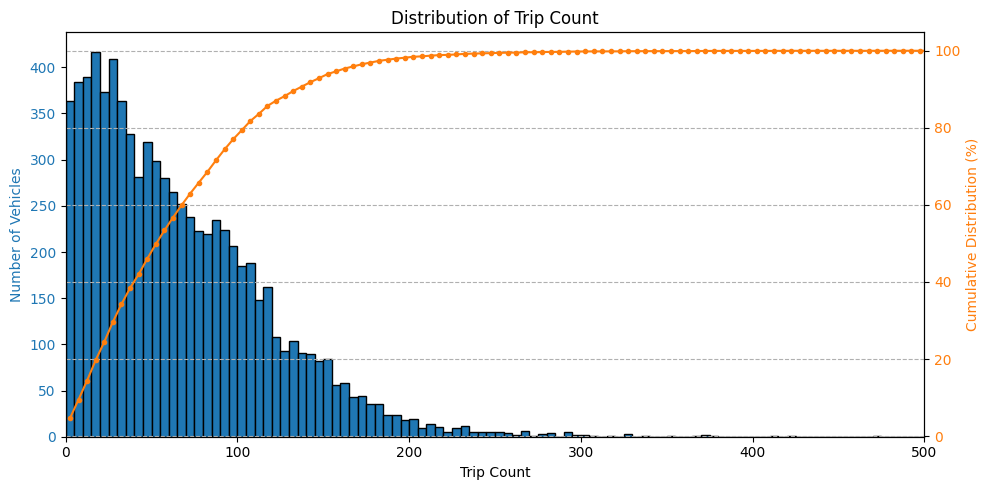

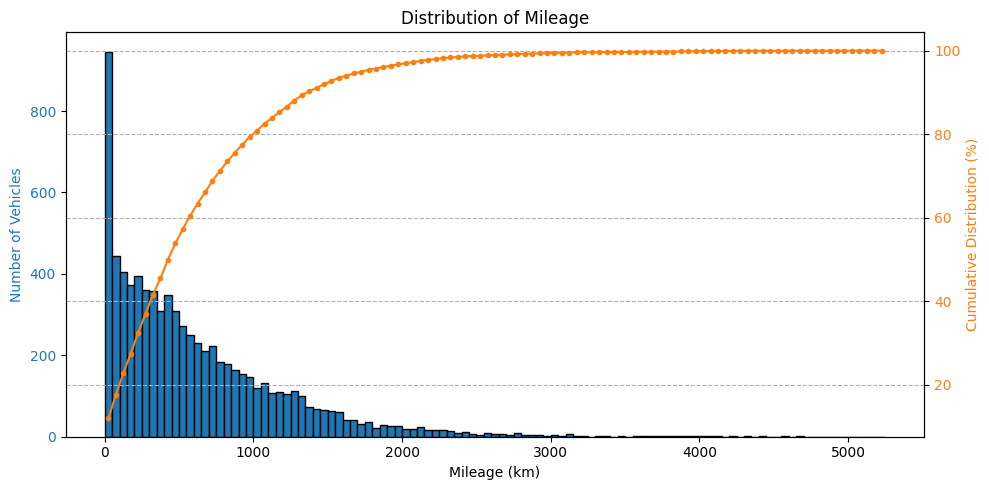

In [0]:
# 描画（トリップ数）
plot_distribution_with_cdf(
    tables_dict['vin_info_pddf'],
    target_col='TRIPCOUNT_DIFF',
    plt_params={
    'figsize': (10, 5),
    'bin_width': 5,
    'bar_color': 'C0',
    'xlabel': 'Trip Count',
    'bar_ylabel': 'Number of Vehicles',
    'bar_yscale': 'linear',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of Trip Count',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    'xlim': (0, 500)
    }
)


# 描画（走行距離）
plot_distribution_with_cdf(
    tables_dict['vin_info_pddf'],
    target_col='ODOMETER_DIFF',
    plt_params={
    'figsize': (10, 5),
    'bin_width': 50,
    'bar_color': 'C0',
    'xlabel': 'Mileage (km)',
    'bar_ylabel': 'Number of Vehicles',
    'bar_yscale': 'linear',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of Mileage',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    'xlim': (None, None)
    }
)

### サーキット訪問頻度（サーキット領域内でのIG-OFF）

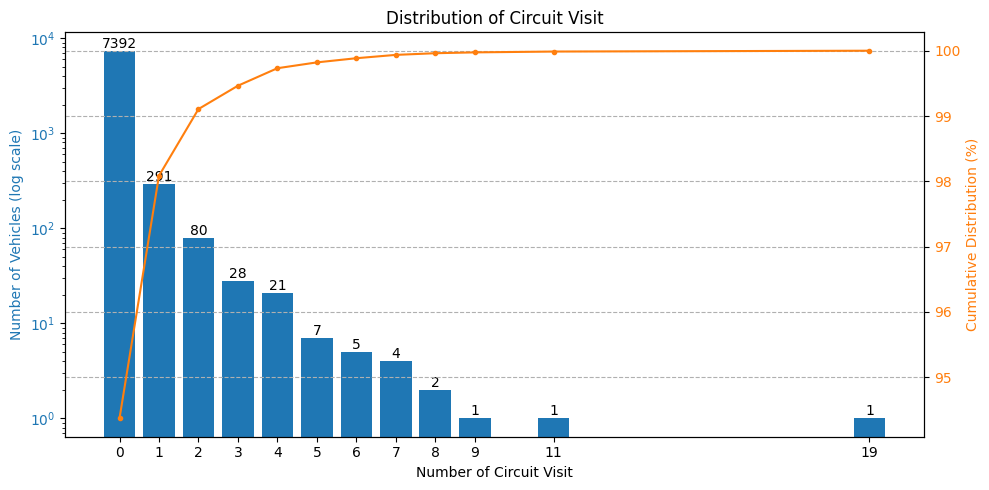

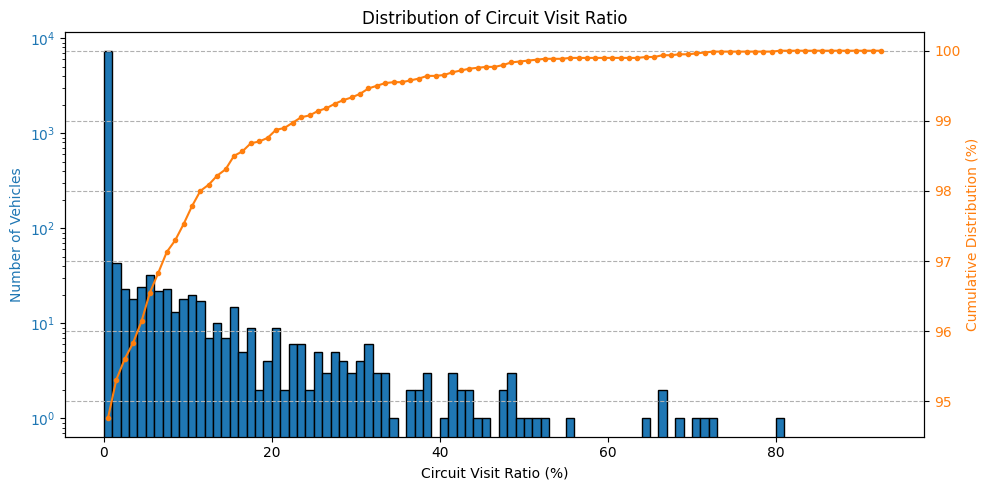

In [0]:
# 描画（訪問回数）
plot_count_distribution_with_cdf(
    tables_dict['trip_circuit_pddf'],
    count_col='TRIP_CIRCUIT_COUNT',
    plt_params={
    'figsize': (10, 5),
    'bar_color': 'C0',
    'xlabel': 'Number of Circuit Visit',
    'bar_ylabel': 'Number of Vehicles (log scale)',
    'bar_yscale': 'log',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of Circuit Visit',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    }
)

# 描画（訪問割合）
plot_distribution_with_cdf(
    tables_dict['trip_circuit_pddf']*100,
    target_col='TRIP_CIRCUIT_RATIO',
    plt_params={
    'figsize': (10, 5),
    'bin_width': 1,
    'bar_color': 'C0',
    'xlabel': 'Circuit Visit Ratio (%)',
    'bar_ylabel': 'Number of Vehicles',
    'bar_yscale': 'log',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of Circuit Visit Ratio',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    'xlim': (None, None)
    }
)

### GR Garage訪問頻度（GR Garage領域内でのIG-OFF）

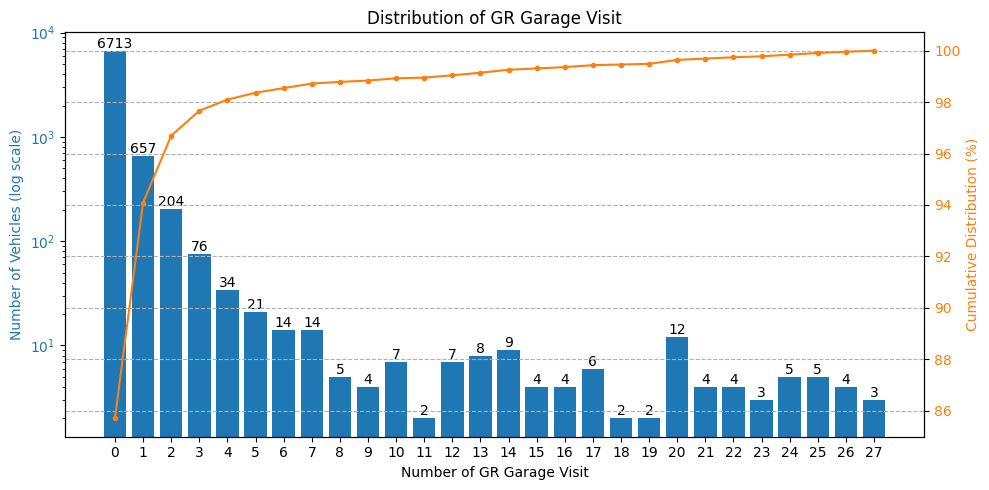

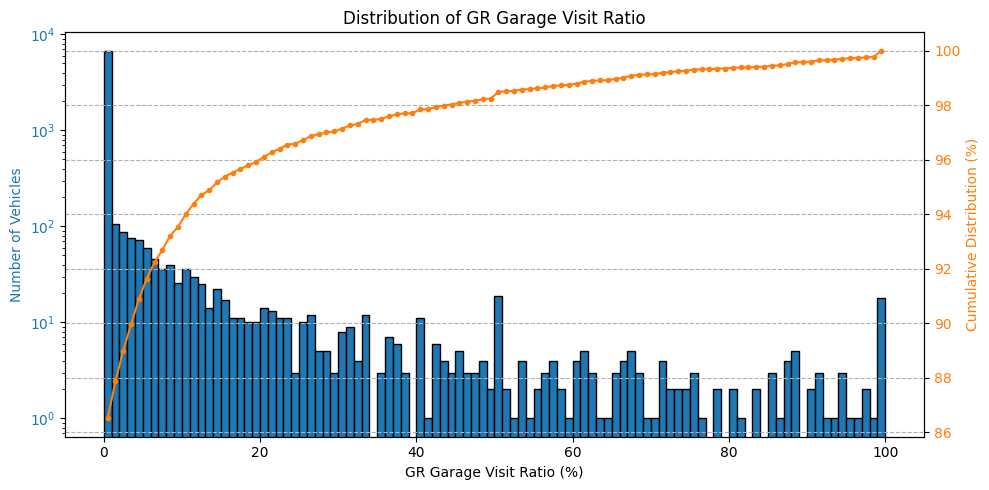

In [0]:
plot_count_distribution_with_cdf(
    tables_dict['trip_grgarage_pddf'],
    count_col='TRIP_GG_COUNT',
    plt_params={
    'figsize': (10, 5),
    'bar_color': 'C0',
    'xlabel': 'Number of GR Garage Visit',
    'bar_ylabel': 'Number of Vehicles (log scale)',
    'bar_yscale': 'log',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of GR Garage Visit',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    }
)

# 描画（訪問割合）
plot_distribution_with_cdf(
    tables_dict['trip_grgarage_pddf']*100,
    target_col='TRIP_GG_RATIO',
    plt_params={
    'figsize': (10, 5),
    'bin_width': 1,
    'bar_color': 'C0',
    'xlabel': 'GR Garage Visit Ratio (%)',
    'bar_ylabel': 'Number of Vehicles',
    'bar_yscale': 'log',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of GR Garage Visit Ratio',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    'xlim': (None, None)
    }
)

## VINの絞り込み

In [0]:
# 抽出結果を保存するディレクトリとファイル名
SAVE_DIR = 'notebook/data/01_select_target_vin'
FILE_NAME = '952w_target_vin_list_dict.pkl'

# VINの絞り込みに必要なデータを抽出
target_vin_list_dict = {}
for key, df_dict in tables_dict_for_prepro_vin_dict.items():
    print(f'[{key}]')
    target_vin_list_dict[key] = filter_vin(
        df_dict,
        vin_list=new_unique_vin_list_dict[key],
        thresholds={
            'tripcount': 10,      # ex.) Target VIN is "tripcount > 10"
            'odometer': 100,      # ex.) Target VIN is "odometer > 10"
            'circuit_days': 10,   # ex.) Target VIN is "circuit visit days < 10
            'circuit_ratio': 0.5, # ex.) Target VIN is "circuit visit ratio < 50 %
            'grgarage_days': 10,  # ex.) Target VIN is "GR Garage visit days < 10
            'grgarage_ratio': 0.5 # ex.) Target VIN is "GR Garage visit ratio < 50 %
        }
)
    
# 抽出結果を保存
save_pkl(SAVE_DIR, FILE_NAME, target_vin_list_dict)

[202410]
Number of VINs: 1949 --> 1526
[202504]
Number of VINs: 4722 --> 4151
[202510]
Number of VINs: 7472 --> 6773
